# Imports

In [57]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import(
    GridSearchCV,
    train_test_split
)

from sklearn.linear_model import LinearRegression
from xgboost import XGBClassifier 
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import r2_score, mean_squared_error, accuracy_score, classification_report

# Data Exploration

## ml_features_and_labels

In [58]:
df = pd.read_csv(r"D:\Downloads\ml_features_and_labels.csv")

In [59]:
df.describe(include='all')

,e2c_total_bytes,e4_entropy_h,e5_entropy_c,e6_time_char,e6b_flow_duration_ms,e2_client_size,e2_client_record_len,e2_server_record_len,e3_cert_parsed,e1_alg_suite_Unknown(0x11eb),...,e1b_ciphersuite_60,e2b_tls_version_SSL3.0,e2b_tls_version_TLS1.0,e2b_ciphersuite_2,e2b_ciphersuite_54,e2b_ciphersuite_60,label,split,taxonomy,ID
count,40010.000000,40010.000000,37500.000000,39010.000000,40010.000000,39510.000000,40010.000000,39010.000000,40010,40010,...,40010,40010,40010,40010,40010,40010,40010.000000,40010,40010,40010
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2,...,2,2,2,2,2,2,NaN,3,5,40010
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,...,True,False,True,False,False,True,NaN,train,ml_baseline_normal,net_high_jitter_classic_run1
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39510,40000,...,39500,40000,40000,40000,39510,39500,NaN,24006,35000,1
mean,12734.864859,4.880134,5.289081,1.882544,46.039189,863.392559,1100.269683,5510.472187,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.125219,NaN,NaN,NaN
std,6276.814331,0.112110,0.699216,1.624671,337.839188,650.984442,652.325633,1383.064765,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.330971,NaN,NaN,NaN
min,285.000000,0.000000,4.001800,0.070000,0.000000,32.000000,129.000000,2.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN
25%,8206.000000,4.812500,4.436600,0.830000,4.619837,32.000000,285.000000,5324.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN
50%,10412.000000,4.875000,5.778700,1.200000,5.376935,1184.000000,1429.000000,5330.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN
75%,19207.000000,4.937500,5.876600,2.460000,6.694078,1568.000000,1813.000000,5333.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN


In [60]:
print("\n=== MISSING VALUES ===")
missing = df.isna().sum()
print(missing[missing > 0].sort_values(ascending=False))


=== MISSING VALUES ===
e5_entropy_c            2510
e6_time_char            1000
e2_server_record_len    1000
e2_client_size           500
dtype: int64


In [61]:
print("\n=== DATA TYPES ===")
print(df.dtypes)


=== DATA TYPES ===
e2c_total_bytes                        int64
e4_entropy_h                         float64
e5_entropy_c                         float64
e6_time_char                         float64
e6b_flow_duration_ms                 float64
e2_client_size                       float64
e2_client_record_len                   int64
e2_server_record_len                 float64
e3_cert_parsed                          bool
e1_alg_suite_Unknown(0x11eb)            bool
e1_alg_suite_Unknown(0x11ec)            bool
e1_alg_suite_mlkem1024                  bool
e1_alg_suite_mlkem768                   bool
e1_alg_suite_x25519                     bool
e1_alg_suite_nan                        bool
e8_proto_context_TLSv1.2_or_older       bool
e8_proto_context_TLSv1.3                bool
e9_conn_outcome_Failure                 bool
e9_conn_outcome_Incomplete              bool
e9_conn_outcome_Success                 bool
e3_sig_alg_Unknown(0x0028)              bool
e3_sig_alg_nan                     

In [62]:
print("\n=== CATEGORICAL VALUES ===")
for col in df.select_dtypes(include=['object']):
        print(f"\n{col}: {df[col].nunique()} unique values")
        print(df[col].value_counts().head(5))


=== CATEGORICAL VALUES ===

split: 3 unique values
split
train    24006
val       8002
test      8002
Name: count, dtype: int64

taxonomy: 5 unique values
taxonomy
ml_baseline_normal      35000
eval_test_network        2000
ml_baseline_anomaly      2000
raf_test_correctness     1000
raf_test_robustness        10
Name: count, dtype: int64

ID: 40010 unique values
ID
net_high_jitter_classic_run1         1
normal_mlkem1024_rsa_cert_run2507    1
normal_mlkem1024_rsa_cert_run2500    1
normal_mlkem1024_rsa_cert_run2501    1
normal_mlkem1024_rsa_cert_run2502    1
Name: count, dtype: int64


In [63]:
l = ['e5_entropy_c','e6_time_char','e2_server_record_len','e2_client_size']

In [64]:
null_dfs = {}
for i in l:
    null_rows = df[df[i].isna()].drop(['split', 'taxonomy','ID'], axis=1)
    unique_rows_df = null_rows.drop_duplicates()
    null_dfs[i] = unique_rows_df

In [65]:
import numpy as np

def apply_half_min_max(df):
    df_mod = df.copy()
    num_cols = df_mod.select_dtypes(include=[np.number]).columns
    mid = len(df_mod) // 2
    for col in num_cols:
        col_min = df_mod[col].min()
        col_max = df_mod[col].max()
        col_idx = df_mod.columns.get_loc(col)
        df_mod.iloc[:mid, col_idx] = col_min
        df_mod.iloc[mid:, col_idx] = col_max
        
    return df_mod



In [66]:
null_dfs = {}
for i in l:
    null_rows = df[df[i].isna()].drop(['split','ID'], axis=1)
    unique_rows_df = null_rows.drop_duplicates()
    null_dfs[i] = unique_rows_df

In [67]:
# This is now a standalone DataFrame of just the unique rows
df1, df2, df3, df4 = null_dfs.values()

In [68]:
df1 = df1.drop_duplicates()
df2 = df2.drop_duplicates()
df3 = df3.drop_duplicates()
df4 = df4.drop_duplicates()

In [69]:
df1 = apply_half_min_max(df1)
df2 = apply_half_min_max(df2)
df3 = apply_half_min_max(df3)
df4 = apply_half_min_max(df4)

In [70]:
df1=pd.read_csv(r'D:\Downloads\e5_entropy_c_Null_Unique_Cases.csv')

In [71]:
df1

,e2c_total_bytes,e4_entropy_h,e5_entropy_c,e6_time_char,e6b_flow_duration_ms,e2_client_size,e2_client_record_len,e2_server_record_len,e3_cert_parsed,e1_alg_suite_Unknown(0x11eb),...,e1b_ciphersuite_2,e1b_ciphersuite_54,e1b_ciphersuite_60,e2b_tls_version_SSL3.0,e2b_tls_version_TLS1.0,e2b_ciphersuite_2,e2b_ciphersuite_54,e2b_ciphersuite_60,label,taxonomy
0,285,0.0,NaN,0.07,0.000000,64.0,129,2.0,False,False,...,False,False,True,False,True,False,False,True,1,eval_test_network
1,285,0.0,NaN,0.07,0.000000,64.0,129,2.0,False,False,...,False,False,True,False,True,False,False,True,1,eval_test_network
2,285,0.0,NaN,0.07,0.000000,64.0,129,2.0,False,False,...,False,False,True,False,True,False,False,True,1,ml_baseline_anomaly
3,285,0.0,NaN,0.07,0.000000,64.0,129,2.0,True,False,...,False,True,False,False,True,False,True,False,1,ml_baseline_anomaly
4,1663,5.0,NaN,8.43,8.430004,1216.0,1519,2.0,True,False,...,False,True,False,False,True,False,True,False,1,ml_baseline_anomaly
5,1663,5.0,NaN,8.43,8.430004,1216.0,1519,2.0,False,False,...,False,False,True,False,True,False,False,True,1,ml_baseline_anomaly
6,1663,5.0,NaN,8.43,8.430004,1216.0,1519,2.0,False,False,...,False,False,True,False,True,False,False,True,1,ml_baseline_anomaly
7,1663,5.0,NaN,8.43,8.430004,1216.0,1519,2.0,False,False,...,False,False,True,False,True,False,False,True,1,raf_test_correctness
8,1663,5.0,NaN,8.43,8.430004,1216.0,1519,2.0,False,True,...,True,False,False,True,False,True,False,False,1,raf_test_robustness


## scenario_manifest

In [72]:
scenario_manifest = pd.read_csv(r"D:\Downloads\scenario_manifest.csv")

In [73]:
scenario_manifest.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40010 entries, 0 to 40009
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   ID                 40010 non-null  object
 1   scenario_id        40010 non-null  object
 2   taxonomy_class     40010 non-null  object
 3   subtype            40010 non-null  object
 4   operational_class  40010 non-null  object
 5   anomaly_label      40010 non-null  object
 6   run_idx            40010 non-null  int64 
dtypes: int64(1), object(6)
memory usage: 2.1+ MB


In [74]:
print("\n=== MISSING VALUES ===")
missing = scenario_manifest.isna().sum()
print(missing[missing > 0].sort_values(ascending=False))


=== MISSING VALUES ===
Series([], dtype: int64)


In [75]:
print("\n=== CATEGORICAL VALUES ===")
lis = scenario_manifest.select_dtypes(include=['object']).columns[1:]
for col in lis:
        print(f"\n{col}: {scenario_manifest[col].nunique()} unique values")
        print(scenario_manifest[col].value_counts().head(21))



=== CATEGORICAL VALUES ===

scenario_id: 21 unique values
scenario_id
normal_mlkem768_mldsa65_cert         3500
normal_mlkem768_rsa_cert             3500
normal_mlkem1024_mldsa65_cert        3500
normal_mlkem1024_mldsa87_cert        3500
normal_mlkem1024_rsa_cert            3500
normal_X25519_rsa_cert               3500
normal_X25519_rsa3072_cert           3500
normal_X25519_ecdsa_p256_cert        3500
normal_X25519_ecdsa_p384_cert        3500
normal_mlkem768_mldsa87_cert         3500
net_high_latency_pqc                  500
threat_data_exfil                     500
net_high_jitter_classic               500
net_high_loss_pqc                     500
anomaly_kem_mismatch                  500
raf_alg_mismatch                      500
raf_downgrade_overt                   500
anomaly_hybrid_pki                    500
anomaly_pqc_over_tls12                500
model_gray_rsa_mimicry                500
raf_robustness_malformed_keyshare      10
Name: count, dtype: int64

taxonomy_class: 5 un

# Data Cleaning

## ml_features_and_labels

In [76]:
df = df.fillna(0)

In [77]:
df.isna().sum().unique()

array([0], dtype=int64)

In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40010 entries, 0 to 40009
Data columns (total 36 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   e2c_total_bytes                    40010 non-null  int64  
 1   e4_entropy_h                       40010 non-null  float64
 2   e5_entropy_c                       40010 non-null  float64
 3   e6_time_char                       40010 non-null  float64
 4   e6b_flow_duration_ms               40010 non-null  float64
 5   e2_client_size                     40010 non-null  float64
 6   e2_client_record_len               40010 non-null  int64  
 7   e2_server_record_len               40010 non-null  float64
 8   e3_cert_parsed                     40010 non-null  bool   
 9   e1_alg_suite_Unknown(0x11eb)       40010 non-null  bool   
 10  e1_alg_suite_Unknown(0x11ec)       40010 non-null  bool   
 11  e1_alg_suite_mlkem1024             40010 non-null  boo

In [79]:
le = LabelEncoder()
df['e9_conn_outcome_Success'] = le.fit_transform(df['e9_conn_outcome_Success'])
df['e9_conn_outcome_Failure'] = le.fit_transform(df['e9_conn_outcome_Failure'])
df['e9_conn_outcome_Incomplete'] = le.fit_transform(df['e9_conn_outcome_Incomplete'])

In [80]:
df['e9_conn_outcome_Incomplete'].value_counts()

e9_conn_outcome_Incomplete
0    39024
1      986
Name: count, dtype: int64

In [81]:
df['e9_conn_outcome_Failure'].value_counts()

e9_conn_outcome_Failure
0    38486
1     1524
Name: count, dtype: int64

In [82]:
df['e9_conn_outcome_Success'].value_counts()

e9_conn_outcome_Success
1    37500
0     2510
Name: count, dtype: int64

In [83]:
lis = df.select_dtypes(include=['bool'])
for col in lis:
    df[col] = le.fit_transform(df[col])

In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40010 entries, 0 to 40009
Data columns (total 36 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   e2c_total_bytes                    40010 non-null  int64  
 1   e4_entropy_h                       40010 non-null  float64
 2   e5_entropy_c                       40010 non-null  float64
 3   e6_time_char                       40010 non-null  float64
 4   e6b_flow_duration_ms               40010 non-null  float64
 5   e2_client_size                     40010 non-null  float64
 6   e2_client_record_len               40010 non-null  int64  
 7   e2_server_record_len               40010 non-null  float64
 8   e3_cert_parsed                     40010 non-null  int64  
 9   e1_alg_suite_Unknown(0x11eb)       40010 non-null  int64  
 10  e1_alg_suite_Unknown(0x11ec)       40010 non-null  int64  
 11  e1_alg_suite_mlkem1024             40010 non-null  int

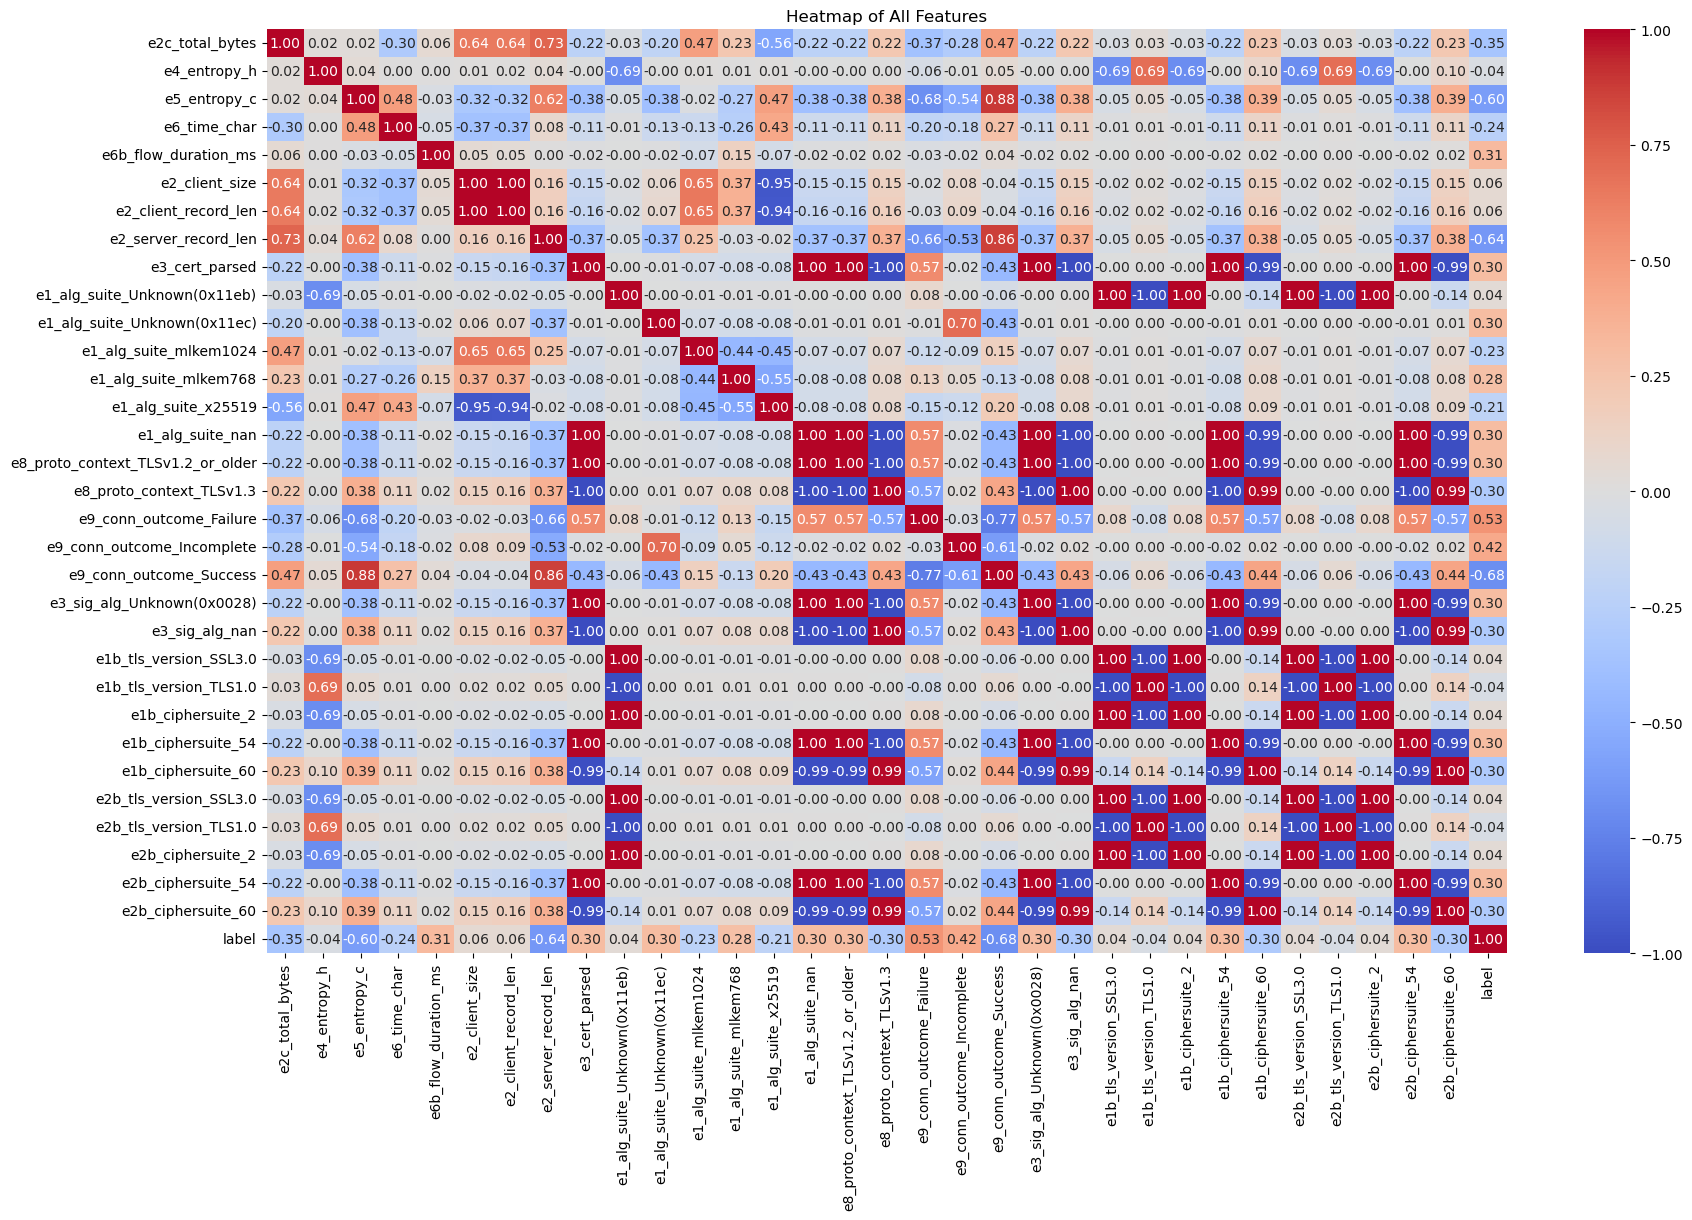

In [85]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(20,12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Heatmap of All Features")
plt.show()

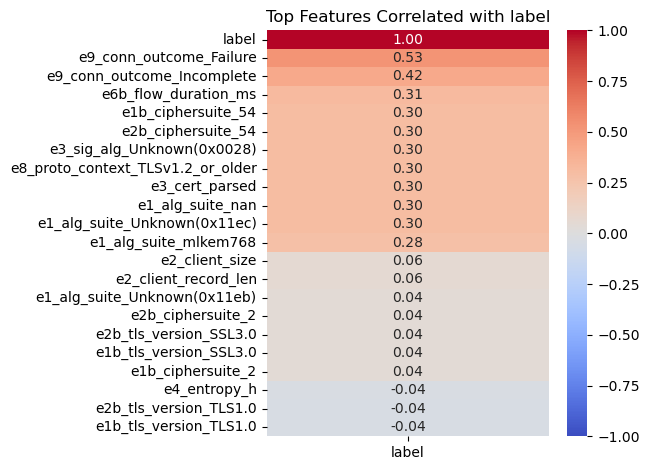

In [86]:
corr = df.corr(numeric_only=True)[['label']].sort_values(by='label', ascending=False)

sns.heatmap(corr.head(22),
            annot=True,
            cmap='coolwarm',
            vmin=-1, vmax=1,
            fmt=".2f")

plt.title("Top Features Correlated with label")
plt.tight_layout()
plt.show()

In [87]:
df.head()

,e2c_total_bytes,e4_entropy_h,e5_entropy_c,e6_time_char,e6b_flow_duration_ms,e2_client_size,e2_client_record_len,e2_server_record_len,e3_cert_parsed,e1_alg_suite_Unknown(0x11eb),...,e1b_ciphersuite_60,e2b_tls_version_SSL3.0,e2b_tls_version_TLS1.0,e2b_ciphersuite_2,e2b_ciphersuite_54,e2b_ciphersuite_60,label,split,taxonomy,ID
0,8182,4.7889,5.8077,2.45,149.827957,32.0,285,5316.0,0,0,...,1,0,1,0,0,1,1,train,eval_test_network,net_high_jitter_classic_run1
1,8126,5.0000,5.8367,2.44,231.020927,32.0,285,5316.0,0,0,...,1,0,1,0,0,1,1,val,eval_test_network,net_high_jitter_classic_run10
2,8272,4.7889,5.9056,2.73,292.967796,32.0,285,5316.0,0,0,...,1,0,1,0,0,1,1,train,eval_test_network,net_high_jitter_classic_run100
3,8272,4.8125,5.9056,2.31,156.050205,32.0,285,5316.0,0,0,...,1,0,1,0,0,1,1,test,eval_test_network,net_high_jitter_classic_run101
4,8272,4.8125,5.8367,4.45,193.972111,32.0,285,5316.0,0,0,...,1,0,1,0,0,1,1,test,eval_test_network,net_high_jitter_classic_run102


## scenario_manifest

In [88]:
scenario_manifest['ID'] = scenario_manifest['ID'].str.replace('.pcap', '', regex=False)

In [89]:
# 2. Create the master 'idx' in the manifest (Step 1)
scenario_manifest['idx'] = range(len(scenario_manifest))

# 3. Create a lookup mapping from the manifest (ID -> idx)
idx_lookup = dict(zip(scenario_manifest['ID'], scenario_manifest['idx']))

# 4. Map the 'idx' to the other file (Steps 2 & 3)
df['idx'] = df['ID'].map(idx_lookup)

In [90]:
df['subtype'] = df['idx'].map(idx_lookup)
df = pd.merge(df, 
              scenario_manifest[['idx', 'subtype']], 
              on='idx', 
              how='left')


In [91]:
# 1. Drop the useless, empty columns
df = df.drop(columns=['subtype_x'])

# 2. Rename the good column back to just 'subtype'
df = df.rename(columns={'subtype_y': 'subtype'})

In [92]:
df

,e2c_total_bytes,e4_entropy_h,e5_entropy_c,e6_time_char,e6b_flow_duration_ms,e2_client_size,e2_client_record_len,e2_server_record_len,e3_cert_parsed,e1_alg_suite_Unknown(0x11eb),...,e2b_tls_version_TLS1.0,e2b_ciphersuite_2,e2b_ciphersuite_54,e2b_ciphersuite_60,label,split,taxonomy,ID,idx,subtype
0,8182,4.7889,5.8077,2.45,149.827957,32.0,285,5316.0,0,0,...,1,0,0,1,1,train,eval_test_network,net_high_jitter_classic_run1,38510,high_jitter_classic
1,8126,5.0000,5.8367,2.44,231.020927,32.0,285,5316.0,0,0,...,1,0,0,1,1,val,eval_test_network,net_high_jitter_classic_run10,38519,high_jitter_classic
2,8272,4.7889,5.9056,2.73,292.967796,32.0,285,5316.0,0,0,...,1,0,0,1,1,train,eval_test_network,net_high_jitter_classic_run100,38609,high_jitter_classic
3,8272,4.8125,5.9056,2.31,156.050205,32.0,285,5316.0,0,0,...,1,0,0,1,1,test,eval_test_network,net_high_jitter_classic_run101,38610,high_jitter_classic
4,8272,4.8125,5.8367,4.45,193.972111,32.0,285,5316.0,0,0,...,1,0,0,1,1,test,eval_test_network,net_high_jitter_classic_run102,38611,high_jitter_classic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40005,285,0.0000,0.0000,0.60,0.598192,64.0,129,2.0,0,1,...,0,1,0,0,1,train,raf_test_robustness,raf_robustness_malformed_keyshare_run5,37504,malformed_keyshare
40006,285,0.0000,0.0000,0.07,0.066996,64.0,129,2.0,0,1,...,0,1,0,0,1,val,raf_test_robustness,raf_robustness_malformed_keyshare_run6,37505,malformed_keyshare
40007,285,0.0000,0.0000,2.91,2.910137,64.0,129,2.0,0,1,...,0,1,0,0,1,train,raf_test_robustness,raf_robustness_malformed_keyshare_run7,37506,malformed_keyshare
40008,285,0.0000,0.0000,0.64,0.639915,64.0,129,2.0,0,1,...,0,1,0,0,1,train,raf_test_robustness,raf_robustness_malformed_keyshare_run8,37507,malformed_keyshare


In [99]:
df_c = df.drop(columns=['ID', 'split', 'taxonomy'])

In [104]:
df_c.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40010 entries, 0 to 40009
Data columns (total 35 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   e2c_total_bytes                    40010 non-null  int64  
 1   e4_entropy_h                       40010 non-null  float64
 2   e5_entropy_c                       40010 non-null  float64
 3   e6_time_char                       40010 non-null  float64
 4   e6b_flow_duration_ms               40010 non-null  float64
 5   e2_client_size                     40010 non-null  float64
 6   e2_client_record_len               40010 non-null  int64  
 7   e2_server_record_len               40010 non-null  float64
 8   e3_cert_parsed                     40010 non-null  int64  
 9   e1_alg_suite_Unknown(0x11eb)       40010 non-null  int64  
 10  e1_alg_suite_Unknown(0x11ec)       40010 non-null  int64  
 11  e1_alg_suite_mlkem1024             40010 non-null  int

## X

In [144]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Clean data (convert bools to 1/0, isolate features)
X = df_c.drop(columns=['subtype', 'idx', 'label'])
X[X.select_dtypes('bool').columns] = X.select_dtypes('bool').astype(int)

# 2. Scale & apply PCA (retaining 90% of total variance)
X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=0.98, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# 3. Output as DataFrame
df_pca = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])
print(f"Reduced from {X.shape[1]} features to {df_pca.shape[1]} principal components.")

Reduced from 32 features to 10 principal components.


In [145]:
df_pca

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
0,0.296303,0.215830,2.574305,0.295482,-0.043679,-0.200891,0.336305,-0.417418,-0.808919,0.004328
1,0.347983,-0.287400,2.572718,0.308553,0.026087,-0.288770,0.558316,-0.480334,1.002365,0.003215
2,0.317912,0.215404,2.620336,0.259865,0.050899,-0.384903,0.716511,-0.293549,-0.808954,0.054569
3,0.309690,0.159174,2.564964,0.277692,-0.031572,-0.223104,0.337533,-0.486464,-0.606811,-0.042745
4,0.360609,0.159846,2.903218,0.219951,-0.129796,-0.141513,0.633189,0.595425,-0.591893,0.437242
...,...,...,...,...,...,...,...,...,...,...
40005,-24.411582,171.773058,0.254503,-3.210683,-0.212559,-0.535871,-0.139396,0.036913,3.146700,-0.054449
40006,-24.425820,171.772941,0.166568,-3.193094,-0.180794,-0.567079,-0.190249,-0.234857,3.142697,-0.168498
40007,-24.349528,171.773565,0.637769,-3.287344,-0.351007,-0.399846,0.082236,1.221424,3.164148,0.442635
40008,-24.410508,171.773067,0.261140,-3.212010,-0.214955,-0.533518,-0.135554,0.057424,3.147002,-0.045841


In [150]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, recall_score, classification_report

# 1. Attach the 'split' and 'label' columns back to your PCA DataFrame
df_pca['split'] = df['split'].values
df_pca['label'] = df['label'].values

# 2. Split using your dataset's defined split column
train_pca = df_pca[df_pca['split'] == 'train'].drop(columns=['split'])
val_pca   = df_pca[df_pca['split'] == 'val'].drop(columns=['split'])
test_pca  = df_pca[df_pca['split'] == 'test'].drop(columns=['split'])

X_train, y_train = train_pca.drop(columns=['label']), train_pca['label']
X_val, y_val     = val_pca.drop(columns=['label']), val_pca['label']
X_test, y_test   = test_pca.drop(columns=['label']), test_pca['label']

# 3. Train XGBoost on PCA features
# Note: Using scale_pos_weight to keep your minority-class recall high
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()

model_pca = xgb.XGBClassifier(
    n_estimators=1550,
    learning_rate=0.15,
    max_depth=8,
    scale_pos_weight=(neg_count / pos_count), # Keeps focus on anomalies
    random_state=42,
    eval_metric='logloss',
    # early_stopping_rounds=20,
    n_jobs=-1
)

model_pca.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False
)

# 4. Predict & Evaluate
preds = model_pca.predict(X_test)

print("--- XGBoost on PCA Features ---")
print(f"Accuracy: {accuracy_score(y_test, preds):.4f}")
print(f"Recall:   {recall_score(y_test, preds, pos_label=1):.4f}\n")
print(classification_report(y_test, preds))

--- XGBoost on PCA Features ---
Accuracy: 0.9588
Recall:   0.8453

              precision    recall  f1-score   support

           0       0.98      0.97      0.98      7000
           1       0.83      0.85      0.84      1002

    accuracy                           0.96      8002
   macro avg       0.90      0.91      0.91      8002
weighted avg       0.96      0.96      0.96      8002



--- Precision-Recall AUC ---
PR-AUC Score: 0.9228



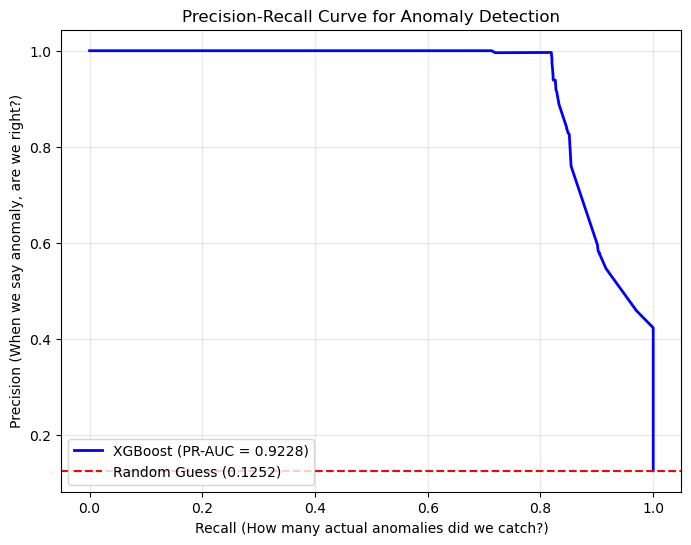

In [151]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

# 1. Get the raw probabilities for the minority class (Anomalies = 1)
# [:, 1] extracts the probability of the positive class
y_probs = best_xgb.predict_proba(X_test)[:, 1]

# 2. Calculate the PR-AUC Score 
# In scikit-learn, average_precision_score mathematically computes the Area Under the PR Curve
pr_auc = average_precision_score(y_test, y_probs)

print(f"--- Precision-Recall AUC ---")
print(f"PR-AUC Score: {pr_auc:.4f}\n")

# 3. Calculate points for the curve
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

# 4. Plot the PR Curve
plt.figure(figsize=(8, 6))

# Plot the model's performance
plt.plot(recall, precision, color='blue', lw=2, label=f'XGBoost (PR-AUC = {pr_auc:.4f})')

# Plot a baseline (what a random guesser would score)
# The baseline for a PR curve is just the ratio of positive instances
baseline = sum(y_test) / len(y_test)
plt.axhline(y=baseline, color='red', linestyle='--', label=f'Random Guess ({baseline:.4f})')

plt.title('Precision-Recall Curve for Anomaly Detection')
plt.xlabel('Recall (How many actual anomalies did we catch?)')
plt.ylabel('Precision (When we say anomaly, are we right?)')
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)

plt.show()

In [152]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40010 entries, 0 to 40009
Data columns (total 38 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   e2c_total_bytes                    40010 non-null  int64  
 1   e4_entropy_h                       40010 non-null  float64
 2   e5_entropy_c                       40010 non-null  float64
 3   e6_time_char                       40010 non-null  float64
 4   e6b_flow_duration_ms               40010 non-null  float64
 5   e2_client_size                     40010 non-null  float64
 6   e2_client_record_len               40010 non-null  int64  
 7   e2_server_record_len               40010 non-null  float64
 8   e3_cert_parsed                     40010 non-null  int64  
 9   e1_alg_suite_Unknown(0x11eb)       40010 non-null  int64  
 10  e1_alg_suite_Unknown(0x11ec)       40010 non-null  int64  
 11  e1_alg_suite_mlkem1024             40010 non-null  int

In [156]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score, precision_score

# Assuming your DataFrame is named 'df' and has 'subtype' and 'label' columns
# label: 0 for normal, 1 for anomaly

# 1. Separate normal traffic from all attacks
df_normal = df[df['subtype'] == 'baseline_normal'].copy()
df_attacks = df[df['subtype'] != 'baseline_normal'].copy()

# 2. Create a static Train/Test split for normal traffic (e.g., 80% train, 20% test)
# We keep this static so the baseline evaluation remains consistent across loops
normal_train, normal_test = train_test_split(df_normal, test_size=0.2, random_state=42)

# 3. Get the list of the 11 unique attack families
attack_families = df_attacks['subtype'].unique()

# 4. Initialize a list to store our metrics
loo_results = []

print("Starting Leave-One-Attack-Out Evaluation...\n")

for attack in attack_families:
    # --- DATA PREP FOR THIS ITERATION ---
    # The unseen test attack (Zero-Day Simulation)
    test_anomalies = df_attacks[df_attacks['subtype'] == attack]
    
    # All other 10 attacks go into the training set
    train_anomalies = df_attacks[df_attacks['subtype'] != attack]
    
    # Combine normal and anomaly data for this specific loop
    train_df = pd.concat([normal_train, train_anomalies])
    test_df = pd.concat([normal_test, test_anomalies])
    
    # Separate features (X) and target (y)
    # Be absolutely sure to drop 'subtype' so the model doesn't cheat!
    drop_cols = ['label', 'subtype', 'ID', 'split', 'taxonomy'] 
    
    X_train = train_df.drop(columns=[c for c in drop_cols if c in train_df.columns])
    y_train = train_df['label']
    
    X_test = test_df.drop(columns=[c for c in drop_cols if c in test_df.columns])
    y_test = test_df['label']
    
    # --- MODEL TRAINING ---
    # Calculate weight dynamically based on this loop's train set
    weight = len(normal_train) / len(train_anomalies)
    
    # Initialize a FRESH model for every loop so it doesn't remember past attacks
    model = xgb.XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=5,
        scale_pos_weight=weight,
        random_state=42,
        eval_metric='logloss',
        n_jobs=-1
    )
    
    model.fit(X_train, y_train)
    
    # --- EVALUATION ---
    preds = model.predict(X_test)
    
    # Calculate recall specifically for this unseen attack
    # Since test_df ONLY contains normal traffic and the ONE unseen attack, 
    # pos_label=1 recall tells us exactly how many of this specific attack were caught.
    recall = recall_score(y_test, preds, pos_label=1)
    precision = precision_score(y_test, preds, pos_label=1, zero_division=0)
    
    loo_results.append({
        'Held-Out Attack': attack,
        'Attack Count': len(test_anomalies),
        'Unseen Recall': round(recall, 4),
        'Precision': round(precision, 4)
    })
    
    print(f"Tested unseen: {attack.ljust(22)} | Zero-Day Recall: {recall:.4f}")

# --- FINAL REPORT ---
print("\n--- Final Leave-One-Out Evaluation Report ---")
results_df = pd.DataFrame(loo_results)
# Sort by lowest recall to instantly see which attacks bypass your system
results_df = results_df.sort_values(by='Unseen Recall', ascending=True)
print(results_df.to_string(index=False))

Starting Leave-One-Attack-Out Evaluation...

Tested unseen: high_jitter_classic    | Zero-Day Recall: 0.0000
Tested unseen: high_latency           | Zero-Day Recall: 1.0000
Tested unseen: high_loss              | Zero-Day Recall: 1.0000
Tested unseen: data_exfil             | Zero-Day Recall: 1.0000
Tested unseen: hybrid_pki             | Zero-Day Recall: 1.0000
Tested unseen: kem_mismatch           | Zero-Day Recall: 0.0000
Tested unseen: pqc_over_tls12         | Zero-Day Recall: 1.0000
Tested unseen: gray_mimicry           | Zero-Day Recall: 1.0000
Tested unseen: raf_alg_mismatch       | Zero-Day Recall: 1.0000
Tested unseen: raf_downgrade_overt    | Zero-Day Recall: 1.0000
Tested unseen: malformed_keyshare     | Zero-Day Recall: 1.0000

--- Final Leave-One-Out Evaluation Report ---
    Held-Out Attack  Attack Count  Unseen Recall  Precision
high_jitter_classic           500            0.0        0.0
       kem_mismatch           500            0.0        0.0
       high_latency     